## Library Calling

In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
time: 2.83 s (started: 2022-05-15 11:10:54 +00:00)


In [79]:
import pandas as pd 
import numpy as np 
import os 
import scipy.stats as stats
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
import string
from sklearn.metrics import classification_report
from sklearn.compose import make_column_selector 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix,plot_confusion_matrix
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings("ignore")
from sklearn import metrics

!pip install ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 2.95 s (started: 2022-05-15 11:10:51 +00:00)


## Data loading



In [81]:
df_CC=pd.read_csv("/content/drive/MyDrive/Python Notebooks/Capstone/Cust_Churn_cleaned.csv")

time: 40.6 ms (started: 2022-05-15 11:10:57 +00:00)


In [82]:
df_CC.drop(['Unnamed: 0','AccountID'],axis=1,inplace=True)

time: 4.22 ms (started: 2022-05-15 11:10:57 +00:00)


In [83]:
df_CC.head()

,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Churn,City_Tier,Payment,Gender,account_segment,Marital_Status,Complain_ly,Login_device
0,4.0,6.0,3.0,3.0,2.0,9.0,11.0,1.0,5.0,159.930000,Yes,Tier-3,Debit Card,Female,Super,Single,Yes,Mobile
1,0.0,8.0,3.0,4.0,3.0,7.0,15.0,0.0,0.0,120.900000,Yes,Tier-1,UPI,Male,Regular Plus,Single,Yes,Mobile
2,0.0,30.0,2.0,4.0,3.0,6.0,14.0,0.0,3.0,132.063333,Yes,Tier-1,Debit Card,Male,Regular Plus,Single,Yes,Mobile
3,0.0,15.0,2.0,4.0,5.0,8.0,23.0,0.0,3.0,134.070000,Yes,Tier-3,Debit Card,Male,Super,Single,No,Mobile
4,0.0,12.0,2.0,3.0,5.0,3.0,11.0,1.0,3.0,129.600000,Yes,Tier-1,Credit Card,Male,Regular Plus,Single,No,Mobile


time: 28.5 ms (started: 2022-05-15 11:10:57 +00:00)


In [84]:
df_CC["Marital_Status"].unique()

array(['Single', 'Divorced', 'Married'], dtype=object)

time: 5.29 ms (started: 2022-05-15 11:10:57 +00:00)


In [85]:
df_CC['Churn'] = df_CC['Churn'].map({'Yes':1,'No':0})
df_CC['City_Tier'] = df_CC['City_Tier'].map({'Tier-1':3,'Tier-2':2,'Tier-3':1})
df_CC['Gender'] = df_CC['Gender'].map({'Male':1,'Female':0})
df_CC['account_segment'] = df_CC['account_segment'].map({'Regular':1,'Regular Plus':2,'HNI':3,'Super':4,'Super Plus':5})
df_CC['Complain_ly'] = df_CC['Complain_ly'].map({'No':0,'Yes':1})

time: 20.9 ms (started: 2022-05-15 11:10:57 +00:00)


In [86]:
df_CC.head()

,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Churn,City_Tier,Payment,Gender,account_segment,Marital_Status,Complain_ly,Login_device
0,4.0,6.0,3.0,3.0,2.0,9.0,11.0,1.0,5.0,159.930000,1,1,Debit Card,0,4,Single,1,Mobile
1,0.0,8.0,3.0,4.0,3.0,7.0,15.0,0.0,0.0,120.900000,1,3,UPI,1,2,Single,1,Mobile
2,0.0,30.0,2.0,4.0,3.0,6.0,14.0,0.0,3.0,132.063333,1,3,Debit Card,1,2,Single,1,Mobile
3,0.0,15.0,2.0,4.0,5.0,8.0,23.0,0.0,3.0,134.070000,1,1,Debit Card,1,4,Single,0,Mobile
4,0.0,12.0,2.0,3.0,5.0,3.0,11.0,1.0,3.0,129.600000,1,3,Credit Card,1,2,Single,0,Mobile


time: 21.2 ms (started: 2022-05-15 11:10:57 +00:00)


In [87]:
df_CC = pd.get_dummies(df_CC,columns = ['Payment','Marital_Status','Login_device'],drop_first=True)
df_CC.head()

,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,...,Gender,account_segment,Complain_ly,Payment_Credit Card,Payment_Debit Card,Payment_E wallet,Payment_UPI,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile
0,4.0,6.0,3.0,3.0,2.0,9.0,11.0,1.0,5.0,159.930000,...,0,4,1,0,1,0,0,0,1,1
1,0.0,8.0,3.0,4.0,3.0,7.0,15.0,0.0,0.0,120.900000,...,1,2,1,0,0,0,1,0,1,1
2,0.0,30.0,2.0,4.0,3.0,6.0,14.0,0.0,3.0,132.063333,...,1,2,1,0,1,0,0,0,1,1
3,0.0,15.0,2.0,4.0,5.0,8.0,23.0,0.0,3.0,134.070000,...,1,4,0,0,1,0,0,0,1,1
4,0.0,12.0,2.0,3.0,5.0,3.0,11.0,1.0,3.0,129.600000,...,1,2,0,1,0,0,0,0,1,1


time: 32.6 ms (started: 2022-05-15 11:10:57 +00:00)


In [88]:
X = df_CC.drop('Churn',axis=1)
y = df_CC['Churn']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30 , random_state=1,stratify = y)

time: 15.1 ms (started: 2022-05-15 11:10:57 +00:00)


## Data Summmary for all Model


In [89]:
def train_summary_l(list):
  for i in list:
   print("summary For Train Data of :", i)
   print("score for {}, is :{}".format (i,round(i.score(X_train,y_train),2)))
   predicted_labels_model = i.predict(X_train)
   print(classification_report(y_train, predicted_labels_model))
   tn, fp, fn, tp = confusion_matrix(y_train, predicted_labels_model).ravel()
   print("True Negative:",tn)
   print("False Negative:",fn)
   print("False Postive:",fp)
   print ("True Postive:",tp)
   plot_confusion_matrix(i, X_train, y_train,cmap='YlGn');
   plt.title("Confusion Matrix for -{}". format(i),fontsize=10);
   plt.grid(False)
   plt.show()
   from sklearn.metrics import precision_recall_fscore_support as score
   precision,recall,fscore,support=score(y_train, predicted_labels_model)
   print("For class 0 Precision:{}; class 1 Precision:{}".format(round(precision[0],2),round(precision[1],2)))
   print("For class 0 recall:{}; class 1 recall:{}".format(round(recall[0],2),round(recall[1],2)))
   print("For class 0 fscore:{}; class 1 fscore:{}".format(round(fscore[0],2),round(fscore[1],2)))
   probs=i.predict_proba(X_train)
   probs=probs[:,1]
   auc=roc_auc_score(y_train, probs)
   print("AUC For {} is :{}".format(i,round(auc,2)))
   train_fpr, train_tpr, train_threshold = roc_curve(y_train, probs)
   plt.plot([0,1],[0,1],linestyle="--")
   plt.title("RoC curve for -{}". format(i),fontsize=10);
   plt.plot(train_fpr, train_tpr,c="green");
   plt.show()
   print("-----------------------------------------------------------------------------------------------------------------------------")

time: 33.2 ms (started: 2022-05-15 11:10:57 +00:00)


In [90]:
def test_summary_l(list):
  for i in list:
    print("summary For Test Data of ", i)
    print("score for {}, is :{}".format (i,round(i.score(X_test,y_test),2)));
    predicted_labels_model = i.predict(X_test)
    print(classification_report(y_test, predicted_labels_model))
    tn, fp, fn, tp = confusion_matrix(y_test, predicted_labels_model).ravel()
    print("True Negative:",tn)
    print("False Negative:",fn)
    print("False Postive:",fp)
    print ("True Postive:",tp)
    plot_confusion_matrix(i, X_test, y_test,cmap='PuRd');
    plt.title("Confusion Matrix for -{}". format(i),fontsize=10);
    plt.grid(False)
    plt.show()
    from sklearn.metrics import precision_recall_fscore_support as score
    precision,recall,fscore,support=score(y_test, predicted_labels_model)
    print("For class 0 Precision:{}; class 1 Precision:{}".format(round(precision[0],2),round(precision[1],2)))
    print("For class 0 recall:{}; class 1 recall:{}".format(round(recall[0],2),round(recall[1],2)))
    print("For class 0 fscore:{}; class 1 fscore:{}".format(round(fscore[0],2),round(fscore[1],2)))
    probs=i.predict_proba(X_test)
    probs=probs[:,1]
    auc=roc_auc_score(y_test, probs)
    print("AUC For {} is :{}".format(i,round(auc,2)))
    test_fpr, test_tpr, test_threshold = roc_curve(y_test, probs)
    plt.plot([0,1],[0,1],linestyle="--")
    plt.title("RoC curve for -{}". format(i),fontsize=10);
    plt.plot(test_fpr, test_tpr,c="red");
    plt.show()
    print("-----------------------------------------------------------------------------------------------------------------------------")

time: 28.2 ms (started: 2022-05-15 11:10:57 +00:00)


In [221]:
def train_summary_m(model):
   model_name = type(model).__name__
   print("summary For Train Data of ", model_name)
   print("score for {}, is :{}".format (model_name,round(model.score(X_train,y_train),2)));
   predicted_labels_model = model.predict(X_train)
   print(classification_report(y_train, predicted_labels_model))
   tn, fp, fn, tp = confusion_matrix(y_train, predicted_labels_model).ravel()
   print("True Negative:",tn)
   print("False Negative:",fn)
   print("False Postive:",fp)
   print ("True Postive:",tp)
   plot_confusion_matrix(model, X_train, y_train,cmap='YlGn');
   plt.title("Confusion Matrix for Train Data-{}". format(model_name),fontsize=10);
   plt.grid(False)
   plt.show()
   from sklearn.metrics import precision_recall_fscore_support as score
   precision,recall,fscore,support=score(y_train, predicted_labels_model)
   print("For class 0 Precision:{}; class 1 Precision:{}".format(round(precision[0],2),round(precision[1],2)))
   print("For class 0 recall:{}; class 1 recall:{}".format(round(recall[0],2),round(recall[1],2)))
   print("For class 0 fscore:{}; class 1 fscore:{}".format(round(fscore[0],2),round(fscore[1],2)))
   probs=model.predict_proba(X_train)
   probs=probs[:,1]
   auc=roc_auc_score(y_train, probs)
   print("AUC For {} is :{}".format(model_name,round(auc,2)))
   train_fpr, train_tpr, train_threshold = roc_curve(y_train, probs)
   plt.plot([0,1],[0,1],linestyle="--")
   plt.title("RoC curve for Train Data -{}". format(model_name),fontsize=10);
   plt.plot(train_fpr, train_tpr,c="green");
   plt.show()
   print("-----------------------------------------------------------------------------------------------------------------------------")

time: 28.3 ms (started: 2022-05-15 13:44:50 +00:00)


In [222]:
def test_summary_m(model):
   model_name = type(model).__name__
   print("summary For Test Data of ", model_name)
   print("score for {}, is :{}".format (model_name,round(model.score(X_test,y_test),2)));
   predicted_labels_model = model.predict(X_test)
   print(classification_report(y_test, predicted_labels_model))
   tn, fp, fn, tp = confusion_matrix(y_test, predicted_labels_model).ravel()
   print("True Negative:",tn)
   print("False Negative:",fn)
   print("False Postive:",fp)
   print ("True Postive:",tp)
   plot_confusion_matrix(model, X_test, y_test,cmap='PuRd');
   plt.title("Confusion Matrix for Test Data -{}". format(model_name),fontsize=10);
   plt.grid(False)
   plt.show()
   from sklearn.metrics import precision_recall_fscore_support as score
   precision,recall,fscore,support=score(y_test, predicted_labels_model)
   print("For class 0 Precision:{}; class 1 Precision:{}".format(round(precision[0],2),round(precision[1],2)))
   print("For class 0 recall:{}; class 1 recall:{}".format(round(recall[0],2),round(recall[1],2)))
   print("For class 0 fscore:{}; class 1 fscore:{}".format(round(fscore[0],2),round(fscore[1],2)))
   probs=model.predict_proba(X_test)
   probs=probs[:,1]
   auc=roc_auc_score(y_test, probs)
   print("AUC For {} is :{}".format(model_name,round(auc,2)))
   test_fpr, test_tpr, test_threshold = roc_curve(y_test, probs)
   plt.plot([0,1],[0,1],linestyle="--")
   plt.title("RoC curve for Test Data -{}". format(model_name),fontsize=10);
   plt.plot(test_fpr, test_tpr,c="red");
   plt.show()
   print("-----------------------------------------------------------------------------------------------------------------------------")

time: 24.4 ms (started: 2022-05-15 13:44:54 +00:00)


### Feature Importance Finder

In [93]:
def feature_importance (model):
  cw=model.coef_
  cn=model.feature_names_in_
  class_weight=[]
  class_name=[]
  for i in range(0,9):
    class_weight.append(round(cw[0][i],2))
    class_name.append(cn[i])
  data={'class_name':class_name,'class_weight':class_weight}
  df_classinfo=pd.DataFrame(data)
  return df_classinfo.sort_values(by='class_weight',ascending=False)

time: 6.34 ms (started: 2022-05-15 11:10:57 +00:00)


# Models


In [94]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

time: 2.67 ms (started: 2022-05-15 11:10:57 +00:00)


## Naive Bayes

In [95]:
from sklearn.naive_bayes import GaussianNB
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

time: 17.2 ms (started: 2022-05-15 11:10:57 +00:00)


### Train Data Performance

summary For Train Data of  GaussianNB
score for GaussianNB, is :0.85
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      6555
           1       0.58      0.40      0.47      1327

    accuracy                           0.85      7882
   macro avg       0.73      0.67      0.69      7882
weighted avg       0.83      0.85      0.84      7882

True Negative: 6174
False Negative: 800
False Postive: 381
True Postive: 527


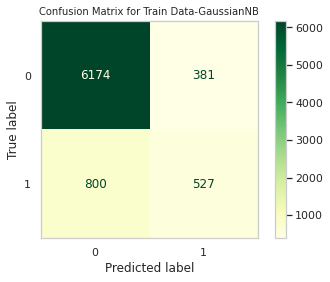

For class 0 Precision:0.89; class 1 Precision:0.58
For class 0 recall:0.94; class 1 recall:0.4
For class 0 fscore:0.91; class 1 fscore:0.47
AUC For GaussianNB is :0.81


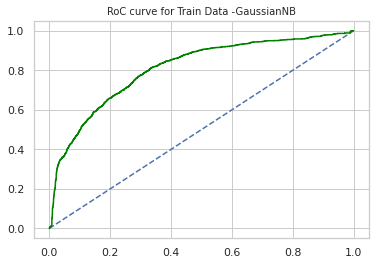

-----------------------------------------------------------------------------------------------------------------------------
time: 486 ms (started: 2022-05-15 13:44:58 +00:00)


In [223]:
train_summary_m(NB_model)

### Test Data Performance

summary For Test Data of  GaussianNB
score for GaussianNB, is :0.85
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2809
           1       0.57      0.39      0.46       569

    accuracy                           0.85      3378
   macro avg       0.73      0.67      0.69      3378
weighted avg       0.83      0.85      0.84      3378

True Negative: 2643
False Negative: 347
False Postive: 166
True Postive: 222


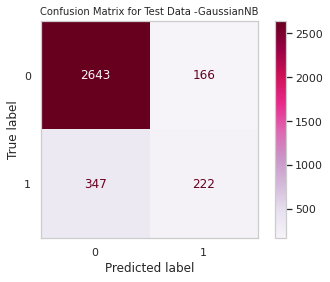

For class 0 Precision:0.88; class 1 Precision:0.57
For class 0 recall:0.94; class 1 recall:0.39
For class 0 fscore:0.91; class 1 fscore:0.46
AUC For GaussianNB is :0.79


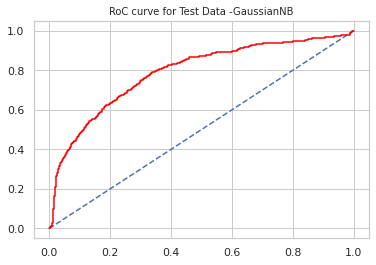

-----------------------------------------------------------------------------------------------------------------------------
time: 582 ms (started: 2022-05-15 13:45:12 +00:00)


In [224]:
test_summary_m(NB_model)

## Decision Tree

In [263]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier()
params_DT = {'criterion':['gini','entropy'],
         'max_depth':list(range(400,501)),
         'min_samples_split':list(range(101,201)),
         'min_samples_leaf':list(range(10,20)),
         'min_impurity_decrease':list(np.random.normal(0.00045,0.00048,500))}
grid_search_DT = RandomizedSearchCV(estimator = model_DT, param_distributions = params_DT, cv = 10,n_jobs=-1,verbose=2,random_state = 1)
grid_search_DT.fit(X_train,y_train)
DT_model = grid_search_DT.best_estimator_
grid_search_DT.best_params_

Fitting 10 folds for each of 10 candidates, totalling 100 fits


{'criterion': 'entropy',
 'max_depth': 484,
 'min_impurity_decrease': 0.00030980401857871854,
 'min_samples_leaf': 15,
 'min_samples_split': 114}

time: 3.41 s (started: 2022-05-15 14:51:56 +00:00)


### Train Data Performance

summary For Train Data of  DecisionTreeClassifier
score for DecisionTreeClassifier, is :0.91
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      6555
           1       0.76      0.65      0.70      1327

    accuracy                           0.91      7882
   macro avg       0.85      0.80      0.82      7882
weighted avg       0.90      0.91      0.90      7882

True Negative: 6282
False Negative: 465
False Postive: 273
True Postive: 862


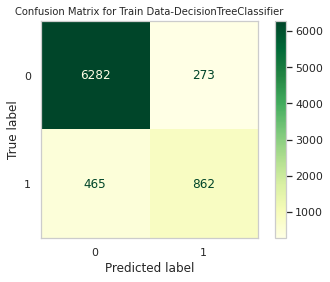

For class 0 Precision:0.93; class 1 Precision:0.76
For class 0 recall:0.96; class 1 recall:0.65
For class 0 fscore:0.94; class 1 fscore:0.7
AUC For DecisionTreeClassifier is :0.95


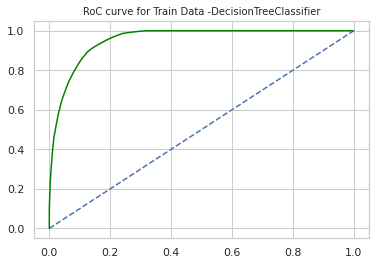

-----------------------------------------------------------------------------------------------------------------------------
time: 501 ms (started: 2022-05-15 14:52:19 +00:00)


In [264]:
train_summary_m(DT_model)

### Test Data Performance

summary For Test Data of  DecisionTreeClassifier
score for DecisionTreeClassifier, is :0.9
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2809
           1       0.73      0.62      0.67       569

    accuracy                           0.90      3378
   macro avg       0.83      0.79      0.80      3378
weighted avg       0.89      0.90      0.89      3378

True Negative: 2676
False Negative: 216
False Postive: 133
True Postive: 353


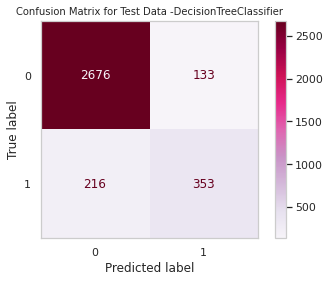

For class 0 Precision:0.93; class 1 Precision:0.73
For class 0 recall:0.95; class 1 recall:0.62
For class 0 fscore:0.94; class 1 fscore:0.67
AUC For DecisionTreeClassifier is :0.93


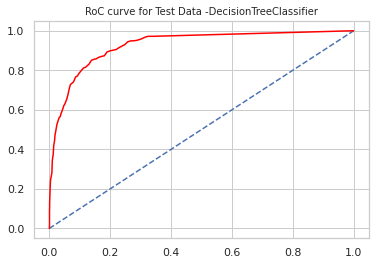

-----------------------------------------------------------------------------------------------------------------------------
time: 480 ms (started: 2022-05-15 14:52:49 +00:00)


In [265]:
test_summary_m(DT_model)

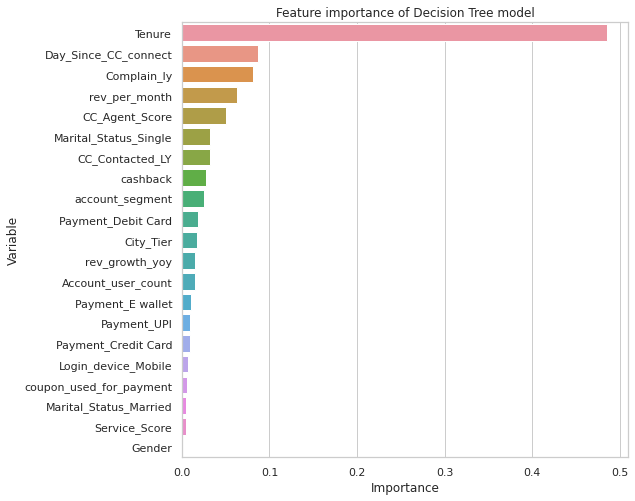

time: 635 ms (started: 2022-05-15 14:07:33 +00:00)


In [252]:
importance = pd.DataFrame({'Variable':X_train.columns,'Importance':DT_model.feature_importances_})
importance = importance.sort_values(by = 'Importance',ascending=False)
fig,axes = plt.subplots(figsize=(8,8))
sns.barplot(y='Variable',x='Importance',data = importance,ci=0)
plt.title("Feature importance of Decision Tree model");
#axes.set_yticklabels(importance['Variable'],rotation=90)
plt.show()

## Random Forest


In [266]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier(random_state=1)
params_RF = {'criterion':['gini','entropy'],
         'n_estimators':list(range(801,900,2)),
         'min_samples_leaf':list(range(1,7)),
         'max_features':list(range(1,7)),
         'max_samples':list(np.arange(0.7,1,0.05))}
grid_search_RF = RandomizedSearchCV(estimator = model_RF, param_distributions = params_RF, cv = 10,n_jobs=-1,verbose=2,random_state=1)
grid_search_RF.fit(X_train,y_train)
RF_model = grid_search_RF.best_estimator_
grid_search_RF.best_params_

Fitting 10 folds for each of 10 candidates, totalling 100 fits


{'criterion': 'gini',
 'max_features': 4,
 'max_samples': 0.9500000000000002,
 'min_samples_leaf': 1,
 'n_estimators': 827}

time: 7min 9s (started: 2022-05-15 14:56:07 +00:00)


### Train Data Performance

summary For Train Data of  RandomForestClassifier
score for RandomForestClassifier, is :1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6555
           1       1.00      1.00      1.00      1327

    accuracy                           1.00      7882
   macro avg       1.00      1.00      1.00      7882
weighted avg       1.00      1.00      1.00      7882

True Negative: 6555
False Negative: 0
False Postive: 0
True Postive: 1327


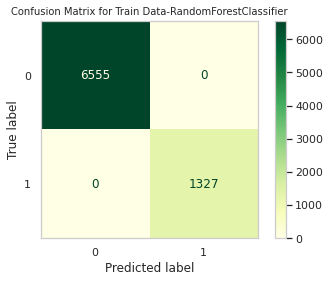

For class 0 Precision:1.0; class 1 Precision:1.0
For class 0 recall:1.0; class 1 recall:1.0
For class 0 fscore:1.0; class 1 fscore:1.0
AUC For RandomForestClassifier is :1.0


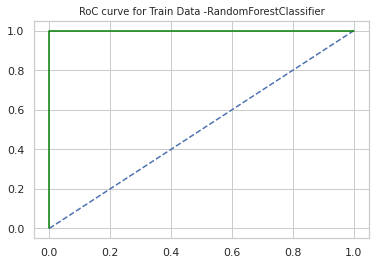

-----------------------------------------------------------------------------------------------------------------------------
time: 4.5 s (started: 2022-05-15 15:03:17 +00:00)


In [267]:
train_summary_m(RF_model)

### Test Data Performance

summary For Test Data of  RandomForestClassifier
score for RandomForestClassifier, is :0.97
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2809
           1       0.98      0.83      0.90       569

    accuracy                           0.97      3378
   macro avg       0.97      0.91      0.94      3378
weighted avg       0.97      0.97      0.97      3378

True Negative: 2799
False Negative: 96
False Postive: 10
True Postive: 473


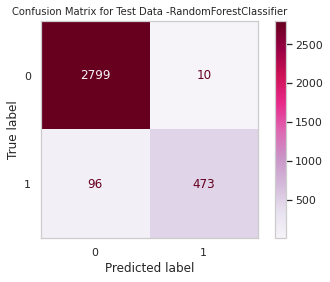

For class 0 Precision:0.97; class 1 Precision:0.98
For class 0 recall:1.0; class 1 recall:0.83
For class 0 fscore:0.98; class 1 fscore:0.9
AUC For RandomForestClassifier is :0.99


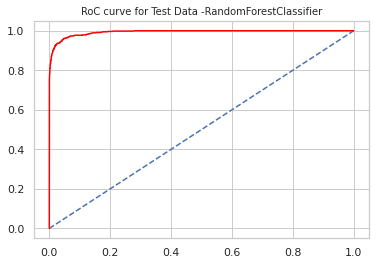

-----------------------------------------------------------------------------------------------------------------------------
time: 2.52 s (started: 2022-05-15 15:03:21 +00:00)


In [268]:
test_summary_m(RF_model)

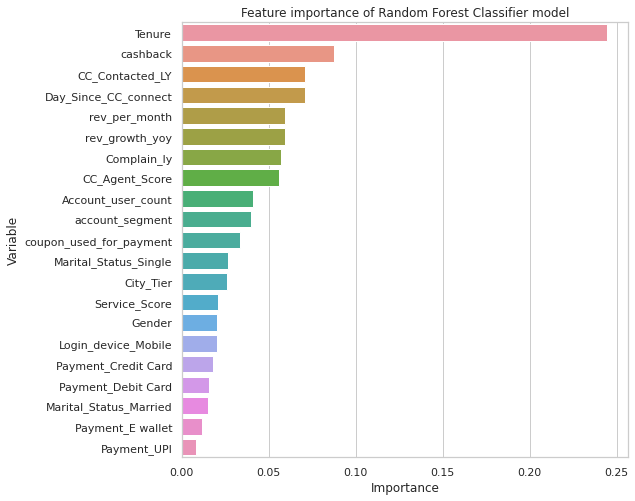

time: 613 ms (started: 2022-05-15 15:03:24 +00:00)


In [269]:
importance = pd.DataFrame({'Variable':X_train.columns,'Importance':RF_model.feature_importances_})
importance = importance.sort_values(by = 'Importance',ascending=False)
fig,axes = plt.subplots(figsize=(8,8))
sns.barplot(y='Variable',x='Importance',data = importance,ci=0)
plt.title("Feature importance of Random Forest Classifier model");
#axes.set_xticklabels(importance['Variable'],rotation=90)
plt.show()

##KNN

In [104]:
from sklearn.neighbors import KNeighborsClassifier
std_scaler = StandardScaler()
model_KNN = KNeighborsClassifier()
pipeline_KNN = Pipeline(steps = [('std_scaler',std_scaler),
                            ('model_KNN',model_KNN)])
params_KNN = {'model_KNN__n_neighbors':list(range(3,21,2)),
         'model_KNN__weights':['uniform','distance'],
         'model_KNN__metric':['euclidean','chebyshev','manhattan']}
grid_search_KNN = GridSearchCV(pipeline_KNN,param_grid = params_KNN,cv=10,n_jobs=-1)
grid_search_KNN.fit(X_train,y_train)
KNN_model = grid_search_KNN.best_estimator_
grid_search_KNN.best_params_

{'model_KNN__metric': 'manhattan',
 'model_KNN__n_neighbors': 3,
 'model_KNN__weights': 'distance'}

time: 1min 6s (started: 2022-05-15 11:17:43 +00:00)


### Train Data Performance

summary For Train Data of  Pipeline
score for Pipeline, is :1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6555
           1       1.00      1.00      1.00      1327

    accuracy                           1.00      7882
   macro avg       1.00      1.00      1.00      7882
weighted avg       1.00      1.00      1.00      7882

True Negative: 6555
False Negative: 0
False Postive: 0
True Postive: 1327


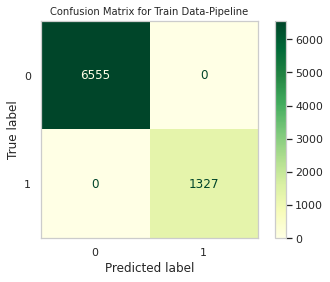

For class 0 Precision:1.0; class 1 Precision:1.0
For class 0 recall:1.0; class 1 recall:1.0
For class 0 fscore:1.0; class 1 fscore:1.0
AUC For Pipeline is :1.0


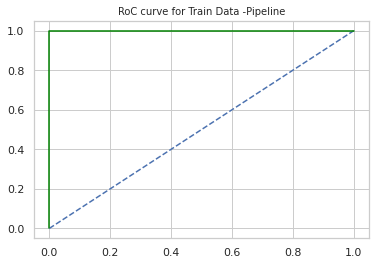

-----------------------------------------------------------------------------------------------------------------------------
time: 5.35 s (started: 2022-05-15 13:53:53 +00:00)


In [232]:
train_summary_m(KNN_model)

### Test Data Performance

summary For Test Data of  Pipeline
score for Pipeline, is :0.97
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2809
           1       0.93      0.91      0.92       569

    accuracy                           0.97      3378
   macro avg       0.96      0.95      0.95      3378
weighted avg       0.97      0.97      0.97      3378

True Negative: 2769
False Negative: 49
False Postive: 40
True Postive: 520


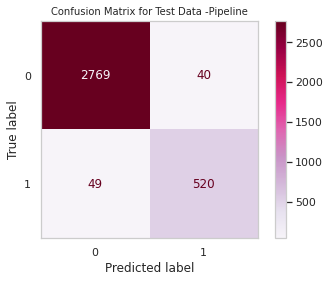

For class 0 Precision:0.98; class 1 Precision:0.93
For class 0 recall:0.99; class 1 recall:0.91
For class 0 fscore:0.98; class 1 fscore:0.92
AUC For Pipeline is :0.98


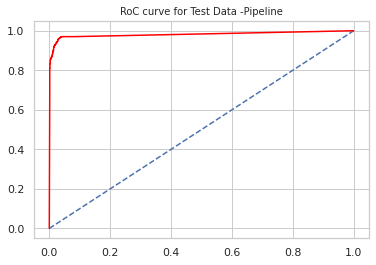

-----------------------------------------------------------------------------------------------------------------------------
time: 2.51 s (started: 2022-05-15 13:53:59 +00:00)


In [233]:
test_summary_m(KNN_model)

##ANN

In [107]:
from sklearn.neural_network import MLPClassifier
model_ANN = MLPClassifier()
pipeline_ANN = Pipeline(steps = [('std_scaler',std_scaler),
                            ('model_ANN',model_ANN)])
param_grid_ANN= {
    'model_ANN__hidden_layer_sizes': [(100,100,100)],
    'model_ANN__activation': ['logistic', 'relu'],
    'model_ANN__solver': ['sgd', 'adam'],
    'model_ANN__tol': [0.1,0.01],
    'model_ANN__max_iter' : [10000]
}
grid_search_ANN= GridSearchCV(estimator = pipeline_ANN, param_grid = param_grid_ANN, cv = 3)
grid_search_ANN.fit(X_train,y_train)
ANN_model = grid_search_ANN.best_estimator_
grid_search_ANN.best_params_

{'model_ANN__activation': 'relu',
 'model_ANN__hidden_layer_sizes': (100, 100, 100),
 'model_ANN__max_iter': 10000,
 'model_ANN__solver': 'adam',
 'model_ANN__tol': 0.01}

time: 2min 10s (started: 2022-05-15 11:18:58 +00:00)


### Train Data Performance

summary For Train Data of  Pipeline
score for Pipeline, is :1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6555
           1       1.00      1.00      1.00      1327

    accuracy                           1.00      7882
   macro avg       1.00      1.00      1.00      7882
weighted avg       1.00      1.00      1.00      7882

True Negative: 6553
False Negative: 3
False Postive: 2
True Postive: 1324


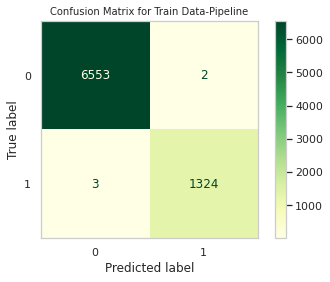

For class 0 Precision:1.0; class 1 Precision:1.0
For class 0 recall:1.0; class 1 recall:1.0
For class 0 fscore:1.0; class 1 fscore:1.0
AUC For Pipeline is :1.0


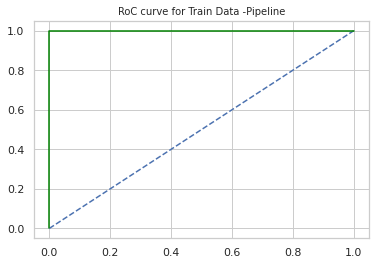

-----------------------------------------------------------------------------------------------------------------------------
time: 722 ms (started: 2022-05-15 13:54:03 +00:00)


In [234]:
train_summary_m(ANN_model)

### Test Data Performance

summary For Test Data of  Pipeline
score for Pipeline, is :0.97
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2809
           1       0.90      0.89      0.90       569

    accuracy                           0.97      3378
   macro avg       0.94      0.94      0.94      3378
weighted avg       0.97      0.97      0.97      3378

True Negative: 2754
False Negative: 61
False Postive: 55
True Postive: 508


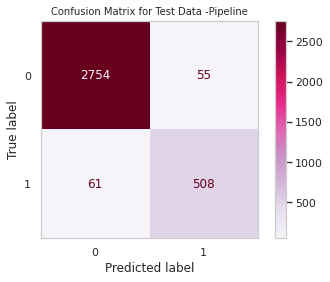

For class 0 Precision:0.98; class 1 Precision:0.9
For class 0 recall:0.98; class 1 recall:0.89
For class 0 fscore:0.98; class 1 fscore:0.9
AUC For Pipeline is :0.98


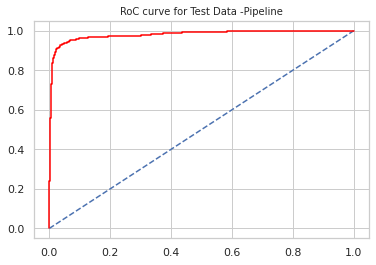

-----------------------------------------------------------------------------------------------------------------------------
time: 597 ms (started: 2022-05-15 13:54:06 +00:00)


In [235]:
test_summary_m(ANN_model)

## Logistic Regression



In [110]:
from sklearn.linear_model import LogisticRegression
grid_LR = {'solver':['newton-cg','lbfgs','sag','saga']}
model_LR = LogisticRegression(max_iter=10000,n_jobs=-1,penalty = 'none')
grid_search_LR = GridSearchCV(estimator = model_LR, param_grid = grid_LR, cv = 10,n_jobs=-1,scoring='accuracy',verbose=2)
grid_search_LR.fit(X_train, y_train.values.ravel())
LR_model = grid_search_LR.best_estimator_
grid_search_LR.best_params_

Fitting 10 folds for each of 4 candidates, totalling 40 fits


{'solver': 'lbfgs'}

time: 4min 39s (started: 2022-05-15 11:21:10 +00:00)


### Train Data Performance

summary For Train Data of  LogisticRegression
score for LogisticRegression, is :0.88
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      6555
           1       0.76      0.43      0.55      1327

    accuracy                           0.88      7882
   macro avg       0.83      0.70      0.74      7882
weighted avg       0.87      0.88      0.87      7882

True Negative: 6380
False Negative: 761
False Postive: 175
True Postive: 566


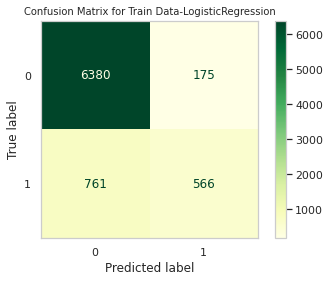

For class 0 Precision:0.89; class 1 Precision:0.76
For class 0 recall:0.97; class 1 recall:0.43
For class 0 fscore:0.93; class 1 fscore:0.55
AUC For LogisticRegression is :0.87


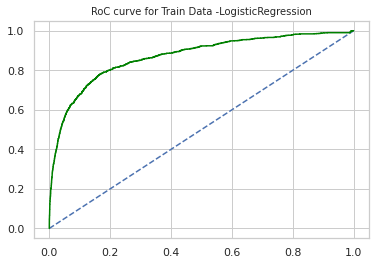

-----------------------------------------------------------------------------------------------------------------------------
time: 560 ms (started: 2022-05-15 13:54:08 +00:00)


In [236]:
train_summary_m(LR_model)

### Test Data Performance

summary For Test Data of  LogisticRegression
score for LogisticRegression, is :0.88
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2809
           1       0.78      0.43      0.56       569

    accuracy                           0.88      3378
   macro avg       0.84      0.70      0.74      3378
weighted avg       0.88      0.88      0.87      3378

True Negative: 2740
False Negative: 323
False Postive: 69
True Postive: 246


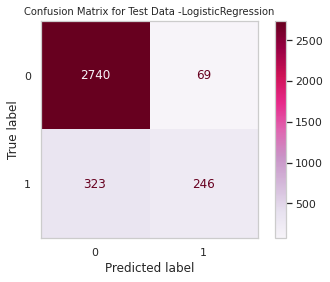

For class 0 Precision:0.89; class 1 Precision:0.78
For class 0 recall:0.98; class 1 recall:0.43
For class 0 fscore:0.93; class 1 fscore:0.56
AUC For LogisticRegression is :0.85


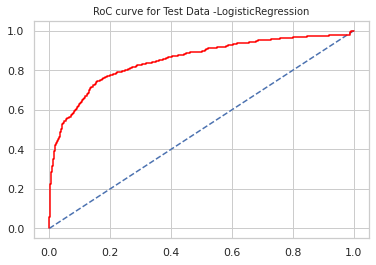

-----------------------------------------------------------------------------------------------------------------------------
time: 528 ms (started: 2022-05-15 13:54:11 +00:00)


In [237]:
test_summary_m(LR_model)

### Treshold Tuning 

In [270]:
from sklearn.metrics import roc_curve
probs=LR_model.predict_proba(X_train)
probs=probs[:,1]
fpr, tpr, thresholds = roc_curve(y_train, probs)

time: 23.9 ms (started: 2022-05-15 16:57:16 +00:00)


In [271]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

0.21859855840868794

time: 12 ms (started: 2022-05-15 16:57:18 +00:00)


In [272]:
y_class_pred=[]
for i in range(0,len(probs)):
    if np.array(probs)[i]>optimal_threshold:
        a=1
    else:
        a=0
    y_class_pred.append(a)

time: 88.7 ms (started: 2022-05-15 16:57:22 +00:00)


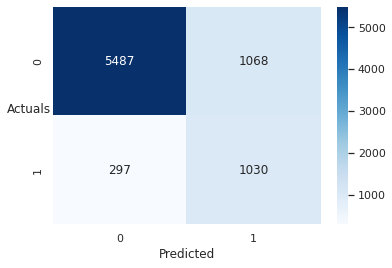

time: 498 ms (started: 2022-05-15 16:57:26 +00:00)


In [273]:
sns.heatmap((metrics.confusion_matrix(y_train, y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [274]:
print(metrics.classification_report(y_train,y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.949     0.837     0.889      6555
           1      0.491     0.776     0.601      1327

    accuracy                          0.827      7882
   macro avg      0.720     0.807     0.745      7882
weighted avg      0.872     0.827     0.841      7882

time: 96.2 ms (started: 2022-05-15 16:57:30 +00:00)


#### Validating on Test

In [279]:
y_prob_pred_test = LR_model.predict(X_test)

time: 20.4 ms (started: 2022-05-15 17:03:02 +00:00)


In [280]:
y_class_pred=[]
for i in range(0,len(y_prob_pred_test)):
    if np.array(y_prob_pred_test)[i]>optimal_threshold:
        a=1
    else:
        a=0
    y_class_pred.append(a)

time: 39 ms (started: 2022-05-15 17:03:05 +00:00)


              precision    recall  f1-score   support

           0      0.895     0.975     0.933      2809
           1      0.781     0.432     0.557       569

    accuracy                          0.884      3378
   macro avg      0.838     0.704     0.745      3378
weighted avg      0.875     0.884     0.870      3378



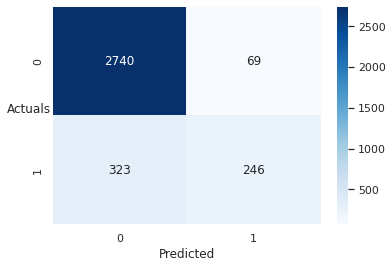

time: 497 ms (started: 2022-05-15 17:03:49 +00:00)


In [283]:
sns.heatmap((metrics.confusion_matrix(y_test,y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);
print(metrics.classification_report(y_test,y_class_pred,digits=3))

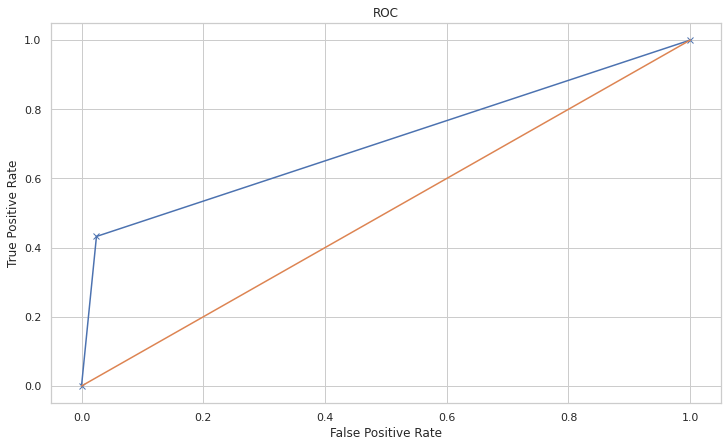

AUC is :0.7
time: 851 ms (started: 2022-05-15 17:04:12 +00:00)


In [284]:
from sklearn.metrics import roc_curve,roc_auc_score
rf_fpr, rf_tpr,_=roc_curve(y_test,y_class_pred)
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Logistic Regression')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
auc=roc_auc_score(y_test,y_class_pred)
print("AUC is :{}".format(round(auc,2)))

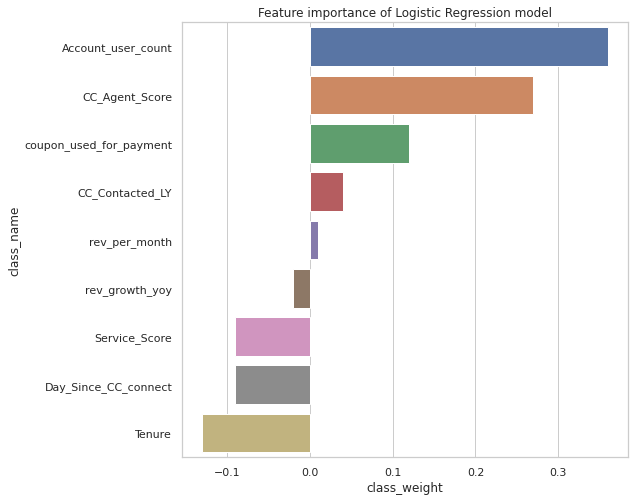

time: 586 ms (started: 2022-05-15 14:27:10 +00:00)


In [256]:
fig,axes = plt.subplots(figsize=(8,8))
sns.barplot(y='class_name',x='class_weight',data = feature_importance(LR_model),ci=0)
plt.title("Feature importance of Logistic Regression model");
#axes.set_xticklabels(importance['Variable'],rotation=90)
plt.show()

## LDA

In [113]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
ldam=LinearDiscriminantAnalysis() 
ldam.fit(X_train, y_train)

LinearDiscriminantAnalysis()

time: 62.1 ms (started: 2022-05-15 11:25:51 +00:00)


### Train Data Performance

summary For Train Data of  LinearDiscriminantAnalysis
score for LinearDiscriminantAnalysis, is :0.87
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      6555
           1       0.74      0.34      0.47      1327

    accuracy                           0.87      7882
   macro avg       0.81      0.66      0.70      7882
weighted avg       0.86      0.87      0.85      7882

True Negative: 6401
False Negative: 878
False Postive: 154
True Postive: 449


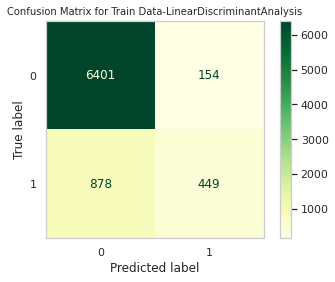

For class 0 Precision:0.88; class 1 Precision:0.74
For class 0 recall:0.98; class 1 recall:0.34
For class 0 fscore:0.93; class 1 fscore:0.47
AUC For LinearDiscriminantAnalysis is :0.84


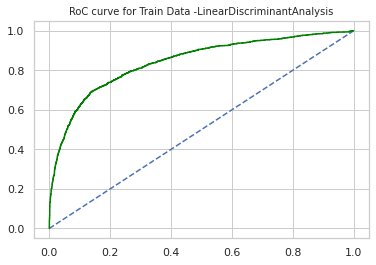

-----------------------------------------------------------------------------------------------------------------------------
time: 549 ms (started: 2022-05-15 13:54:14 +00:00)


In [238]:
train_summary_m(ldam)

### Test Data Performance

summary For Test Data of  LinearDiscriminantAnalysis
score for LinearDiscriminantAnalysis, is :0.87
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2809
           1       0.78      0.35      0.48       569

    accuracy                           0.87      3378
   macro avg       0.83      0.67      0.71      3378
weighted avg       0.86      0.87      0.85      3378

True Negative: 2751
False Negative: 369
False Postive: 58
True Postive: 200


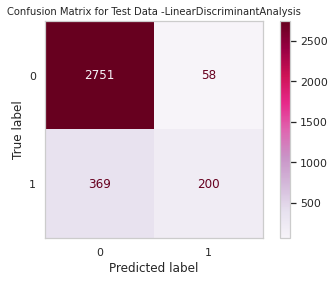

For class 0 Precision:0.88; class 1 Precision:0.78
For class 0 recall:0.98; class 1 recall:0.35
For class 0 fscore:0.93; class 1 fscore:0.48
AUC For LinearDiscriminantAnalysis is :0.83


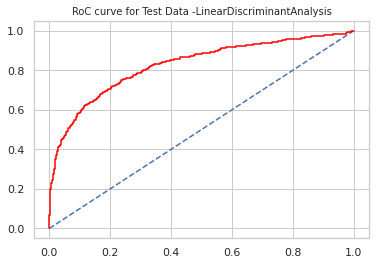

-----------------------------------------------------------------------------------------------------------------------------
time: 547 ms (started: 2022-05-15 13:54:16 +00:00)


In [239]:
test_summary_m(ldam)

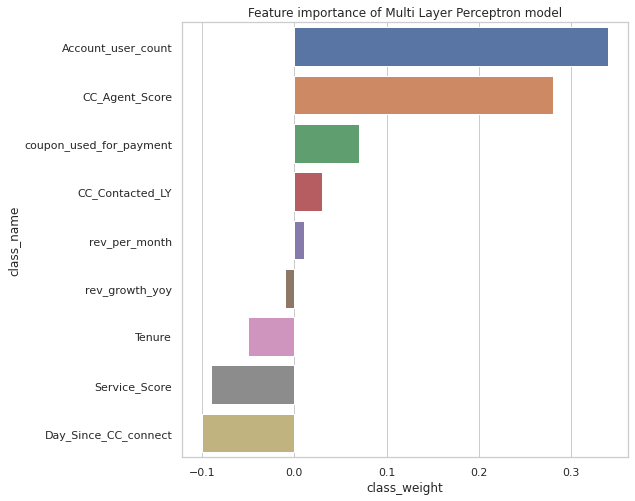

time: 1.11 s (started: 2022-05-15 17:16:07 +00:00)


In [289]:
fig,axes = plt.subplots(figsize=(8,8))
sns.barplot(y='class_name',x='class_weight',data = feature_importance(ldam),ci=0)
plt.title("Feature importance of Multi Layer Perceptron model");
#axes.set_xticklabels(importance['Variable'],rotation=90)
plt.show()

### Treshold Tuning 

In [117]:
from sklearn.metrics import roc_curve
probs=ldam.predict_proba(X_train)
probs=probs[:,1]
fpr, tpr, thresholds = roc_curve(y_train, probs)

time: 16.6 ms (started: 2022-05-15 11:25:52 +00:00)


In [118]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

0.2432096901025069

time: 8.49 ms (started: 2022-05-15 11:25:52 +00:00)


In [119]:
y_class_pred=[]
for i in range(0,len(probs)):
    if np.array(probs)[i]>optimal_threshold:
        a=1
    else:
        a=0
    y_class_pred.append(a)

time: 54.9 ms (started: 2022-05-15 11:25:52 +00:00)


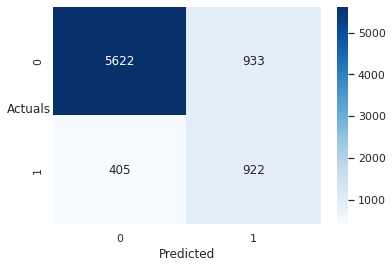

time: 251 ms (started: 2022-05-15 11:25:52 +00:00)


In [120]:
sns.heatmap((metrics.confusion_matrix(y_train, y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [121]:
print(metrics.classification_report(y_train,y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.933     0.858     0.894      6555
           1      0.497     0.695     0.580      1327

    accuracy                          0.830      7882
   macro avg      0.715     0.776     0.737      7882
weighted avg      0.859     0.830     0.841      7882

time: 28.3 ms (started: 2022-05-15 11:25:52 +00:00)


#### Validating on Test

In [285]:
y_prob_pred_test = ldam.predict(X_test)

time: 26.2 ms (started: 2022-05-15 17:06:05 +00:00)


In [286]:
y_class_pred=[]
for i in range(0,len(y_prob_pred_test)):
    if np.array(y_prob_pred_test)[i]>optimal_threshold:
        a=1
    else:
        a=0
    y_class_pred.append(a)

time: 51.6 ms (started: 2022-05-15 17:06:07 +00:00)


              precision    recall  f1-score   support

           0      0.882     0.979     0.928      2809
           1      0.775     0.351     0.484       569

    accuracy                          0.874      3378
   macro avg      0.828     0.665     0.706      3378
weighted avg      0.864     0.874     0.853      3378



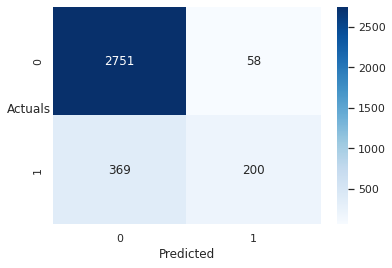

time: 254 ms (started: 2022-05-15 17:06:10 +00:00)


In [287]:
sns.heatmap((metrics.confusion_matrix(y_test,y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);
print(metrics.classification_report(y_test,y_class_pred,digits=3))

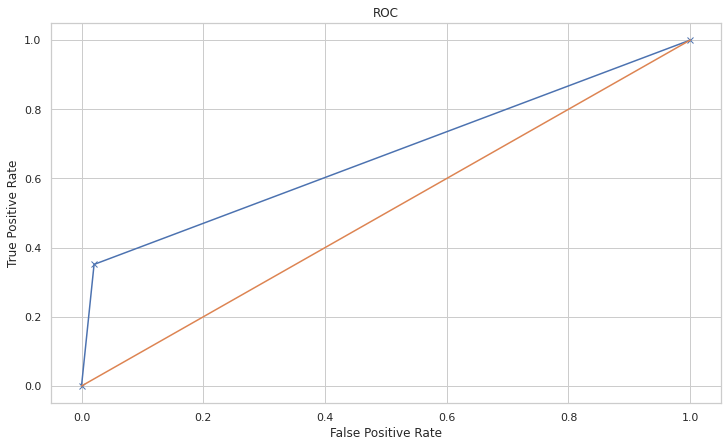

AUC is :0.67
time: 310 ms (started: 2022-05-15 17:06:14 +00:00)


In [288]:
from sklearn.metrics import roc_curve,roc_auc_score
rf_fpr, rf_tpr,_=roc_curve(y_test,y_class_pred)
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Logistic Regression')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
auc=roc_auc_score(y_test,y_class_pred)
print("AUC is :{}".format(round(auc,2)))

## Support Vector Classification

In [122]:
from sklearn.svm import SVC
model_SVC = SVC(probability=True)
pipeline_SVC = Pipeline(steps = [('std_scaler',std_scaler),
                            ('model_SVC',model_SVC)])
params_SVC = {'model_SVC__kernel':['linear','rbf','sigmoid'],
             'model_SVC__C':list(np.arange(1,1.2,0.00001))}
grid_search_SVC = RandomizedSearchCV(pipeline_SVC,param_distributions = params_SVC,cv=3,n_jobs=-1,verbose=2,random_state=1234)
grid_search_SVC.fit(X_train,y_train)
SVC_model = grid_search_SVC.best_estimator_
grid_search_SVC.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'model_SVC__C': 1.1374600000009005, 'model_SVC__kernel': 'rbf'}

time: 1min 47s (started: 2022-05-15 11:25:52 +00:00)


### Train Data Performance

summary For Train Data of  Pipeline
score for Pipeline, is :0.94
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      6555
           1       0.93      0.68      0.79      1327

    accuracy                           0.94      7882
   macro avg       0.94      0.84      0.88      7882
weighted avg       0.94      0.94      0.93      7882

True Negative: 6491
False Negative: 424
False Postive: 64
True Postive: 903


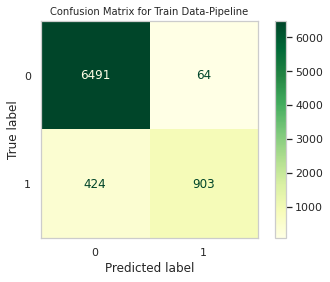

For class 0 Precision:0.94; class 1 Precision:0.93
For class 0 recall:0.99; class 1 recall:0.68
For class 0 fscore:0.96; class 1 fscore:0.79
AUC For Pipeline is :0.96


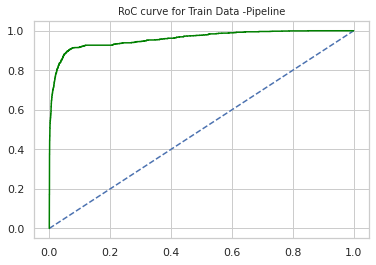

-----------------------------------------------------------------------------------------------------------------------------
time: 6.8 s (started: 2022-05-15 13:54:19 +00:00)


In [240]:
train_summary_m(SVC_model)

### Test Data Performance

summary For Test Data of  Pipeline
score for Pipeline, is :0.92
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      2809
           1       0.92      0.58      0.71       569

    accuracy                           0.92      3378
   macro avg       0.92      0.79      0.83      3378
weighted avg       0.92      0.92      0.91      3378

True Negative: 2779
False Negative: 238
False Postive: 30
True Postive: 331


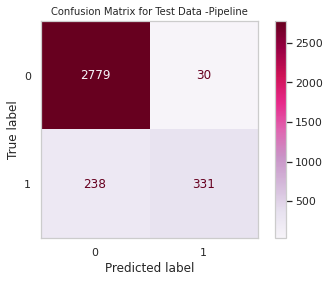

For class 0 Precision:0.92; class 1 Precision:0.92
For class 0 recall:0.99; class 1 recall:0.58
For class 0 fscore:0.95; class 1 fscore:0.71
AUC For Pipeline is :0.93


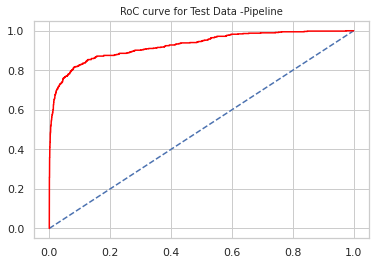

-----------------------------------------------------------------------------------------------------------------------------
time: 3.06 s (started: 2022-05-15 13:54:26 +00:00)


In [241]:
test_summary_m(SVC_model)

# Ensemble  models

##Adaptive Boosting

In [125]:
from sklearn.ensemble import AdaBoostClassifier
model_ADA = AdaBoostClassifier(random_state=1234)
params_ADA = {'n_estimators':list(np.arange(441,502,2)),
             'learning_rate':list(np.arange(0.11,0.2,0.000001))}
grid_search_ADA = RandomizedSearchCV(estimator = model_ADA, param_distributions = params_ADA, cv = 10,n_jobs=-1,verbose=2,random_state=1234)
grid_search_ADA.fit(X_train,y_train)
ADA_model = grid_search_ADA.best_estimator_
grid_search_ADA.best_params_

Fitting 10 folds for each of 10 candidates, totalling 100 fits


{'learning_rate': 0.13803200000002802, 'n_estimators': 489}

time: 4min 25s (started: 2022-05-15 11:27:49 +00:00)


### Train Data Performance

summary For Train Data of  AdaBoostClassifier
score for AdaBoostClassifier, is :0.9
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      6555
           1       0.76      0.57      0.65      1327

    accuracy                           0.90      7882
   macro avg       0.84      0.77      0.80      7882
weighted avg       0.89      0.90      0.89      7882

True Negative: 6316
False Negative: 565
False Postive: 239
True Postive: 762


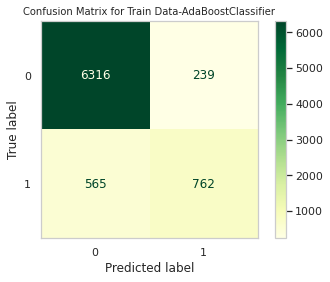

For class 0 Precision:0.92; class 1 Precision:0.76
For class 0 recall:0.96; class 1 recall:0.57
For class 0 fscore:0.94; class 1 fscore:0.65
AUC For AdaBoostClassifier is :0.92


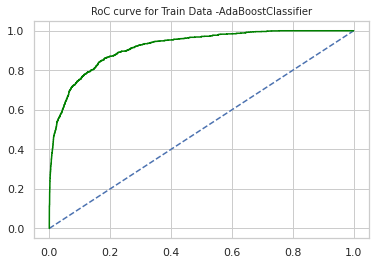

-----------------------------------------------------------------------------------------------------------------------------
time: 3.27 s (started: 2022-05-15 13:54:29 +00:00)


In [242]:
train_summary_m(ADA_model)

### Test Data Performance

summary For Test Data of  AdaBoostClassifier
score for AdaBoostClassifier, is :0.9
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2809
           1       0.78      0.57      0.66       569

    accuracy                           0.90      3378
   macro avg       0.85      0.77      0.80      3378
weighted avg       0.89      0.90      0.89      3378

True Negative: 2715
False Negative: 242
False Postive: 94
True Postive: 327


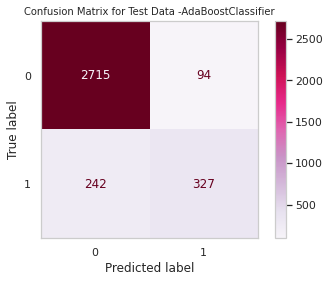

For class 0 Precision:0.92; class 1 Precision:0.78
For class 0 recall:0.97; class 1 recall:0.57
For class 0 fscore:0.94; class 1 fscore:0.66
AUC For AdaBoostClassifier is :0.91


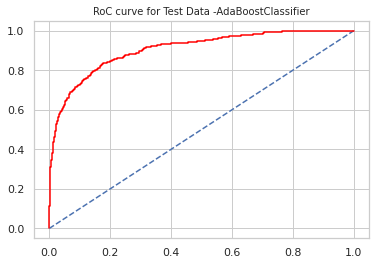

-----------------------------------------------------------------------------------------------------------------------------
time: 1.88 s (started: 2022-05-15 13:54:32 +00:00)


In [243]:
test_summary_m(ADA_model)

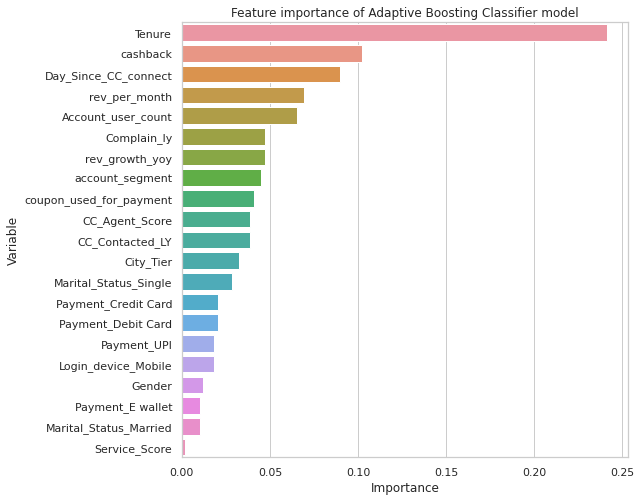

time: 698 ms (started: 2022-05-15 14:48:30 +00:00)


In [258]:
importance = pd.DataFrame({'Variable':X_train.columns,'Importance':ADA_model.feature_importances_})
importance = importance.sort_values(by = 'Importance',ascending=False)
fig,axes = plt.subplots(figsize=(8,8))
sns.barplot(y='Variable',x='Importance',data = importance,ci=0)
plt.title("Feature importance of Adaptive Boosting Classifier model");
#axes.set_xticklabels(importance['Variable'],rotation=90)
plt.show()

## XG Boosting

In [128]:
from sklearn.ensemble import GradientBoostingClassifier
model_XGB = GradientBoostingClassifier(random_state=1234)
params_XGB = {'learning_rate':list(np.arange(0.01,0.02,0.0000001)),
             'n_estimators':list(np.arange(121,140,2)),
             'subsample':list(np.arange(.21,.25,0.01)),
             'min_samples_split':list(np.arange(4,10)),
             'min_samples_leaf':list(np.arange(1,10))}
grid_search_XGB = RandomizedSearchCV(estimator = model_XGB, param_distributions = params_XGB, cv = 10,n_jobs=-1,verbose=2,random_state=1)
grid_search_XGB.fit(X_train,y_train)
XGB_model=grid_search_XGB.best_estimator_
grid_search_XGB.best_params_

Fitting 10 folds for each of 10 candidates, totalling 100 fits


{'learning_rate': 0.019155799999945627,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 133,
 'subsample': 0.25}

time: 46 s (started: 2022-05-15 11:32:20 +00:00)


### Train Data Performance

summary For Train Data of  GradientBoostingClassifier
score for GradientBoostingClassifier, is :0.9
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      6555
           1       0.80      0.53      0.64      1327

    accuracy                           0.90      7882
   macro avg       0.86      0.75      0.79      7882
weighted avg       0.89      0.90      0.89      7882

True Negative: 6381
False Negative: 628
False Postive: 174
True Postive: 699


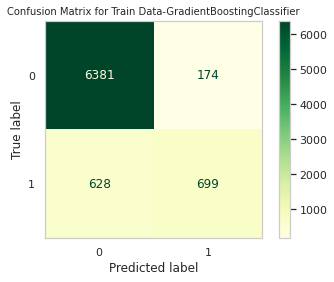

For class 0 Precision:0.91; class 1 Precision:0.8
For class 0 recall:0.97; class 1 recall:0.53
For class 0 fscore:0.94; class 1 fscore:0.64
AUC For GradientBoostingClassifier is :0.91


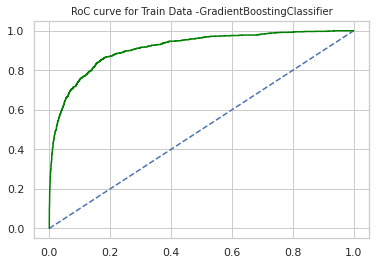

-----------------------------------------------------------------------------------------------------------------------------
time: 553 ms (started: 2022-05-15 13:54:34 +00:00)


In [244]:
train_summary_m(XGB_model)

### Test Data Performance

summary For Test Data of  GradientBoostingClassifier
score for GradientBoostingClassifier, is :0.9
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      2809
           1       0.81      0.50      0.62       569

    accuracy                           0.90      3378
   macro avg       0.86      0.74      0.78      3378
weighted avg       0.89      0.90      0.89      3378

True Negative: 2742
False Negative: 282
False Postive: 67
True Postive: 287


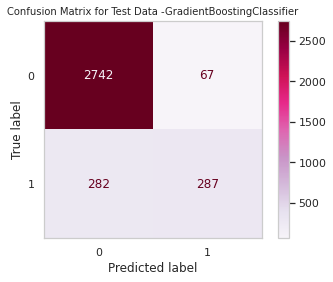

For class 0 Precision:0.91; class 1 Precision:0.81
For class 0 recall:0.98; class 1 recall:0.5
For class 0 fscore:0.94; class 1 fscore:0.62
AUC For GradientBoostingClassifier is :0.9


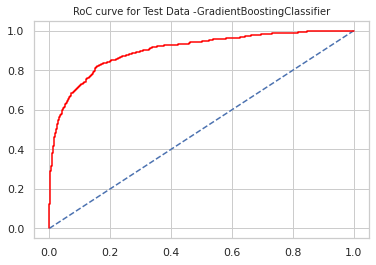

-----------------------------------------------------------------------------------------------------------------------------
time: 523 ms (started: 2022-05-15 13:54:34 +00:00)


In [245]:
test_summary_m(XGB_model)

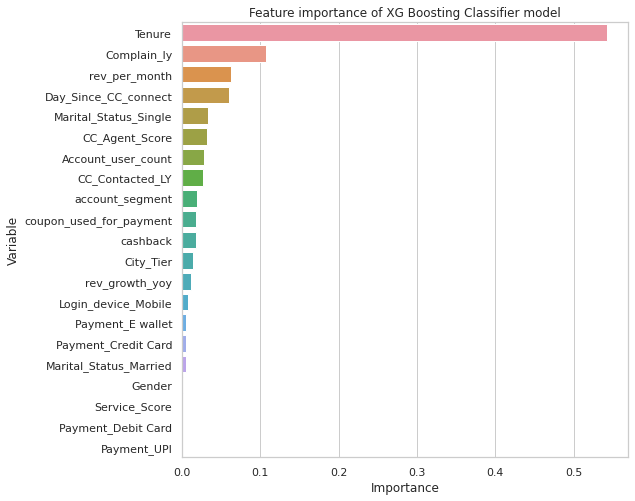

time: 1.13 s (started: 2022-05-15 14:40:15 +00:00)


In [257]:
importance = pd.DataFrame({'Variable':X_train.columns,'Importance':XGB_model.feature_importances_})
importance = importance.sort_values(by = 'Importance',ascending=False)
fig,axes = plt.subplots(figsize=(8,8))
sns.barplot(y='Variable',x='Importance',data = importance,ci=0)
plt.title("Feature importance of XG Boosting Classifier model");
#axes.set_xticklabels(importance['Variable'],rotation=90)
plt.show()

## Voting Classifier (Hetrogeneous)

In [131]:
#model_List
mod_list = [NB_model,DT_model,KNN_model,ANN_model,RF_model,ldam,LR_model,SVC_model,ADA_model,XGB_model]
mod = ["NB_model","DT_model","KNN_model","ANN_model","RF_model","LDA_model","LR_model","SVC_Model","ADA_model","XGB_model"]

time: 2.35 ms (started: 2022-05-15 11:33:07 +00:00)


In [132]:
from sklearn.ensemble import VotingClassifier
estim_list=[]
for i in range(0,10):
  estim_list.append ((mod[i],mod_list[i]))
estim_list

[('NB_model', GaussianNB()),
 ('DT_model', DecisionTreeClassifier(criterion='entropy', max_depth=442,
                         min_impurity_decrease=0.0005867593752795177,
                         min_samples_leaf=18, min_samples_split=102)),
 ('KNN_model', Pipeline(steps=[('std_scaler', StandardScaler()),
                  ('model_KNN',
                   KNeighborsClassifier(metric='manhattan', n_neighbors=3,
                                        weights='distance'))])),
 ('ANN_model', Pipeline(steps=[('std_scaler', StandardScaler()),
                  ('model_ANN',
                   MLPClassifier(hidden_layer_sizes=(100, 100, 100),
                                 max_iter=10000, tol=0.01))])),
 ('RF_model', RandomForestClassifier(criterion='entropy', max_features=3,
                         max_samples=0.8500000000000001, n_estimators=851,
                         random_state=1)),
 ('LDA_model', LinearDiscriminantAnalysis()),
 ('LR_model', LogisticRegression(max_iter=10000, n_j

time: 26.3 ms (started: 2022-05-15 11:33:07 +00:00)


In [133]:
from sklearn.ensemble import VotingClassifier
VOTbyW_model = VotingClassifier(estimators = estim_list,voting = 'soft',weights = [16,16,16,15,11,12,14,16,16,16])
VOTbyW_model.fit(X_train,y_train)

VotingClassifier(estimators=[('NB_model', GaussianNB()),
                             ('DT_model',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=442,
                                                     min_impurity_decrease=0.0005867593752795177,
                                                     min_samples_leaf=18,
                                                     min_samples_split=102)),
                             ('KNN_model',
                              Pipeline(steps=[('std_scaler', StandardScaler()),
                                              ('model_KNN',
                                               KNeighborsClassifier(metric='manhattan',
                                                                    n_neighbors=3,
                                                                    weights='d...
                                               SVC(C=1.1374600000009005,


time: 27.1 s (started: 2022-05-15 11:33:07 +00:00)


### Train Data Performance

summary For Train Data of  VotingClassifier
score for VotingClassifier, is :0.96
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      6555
           1       0.99      0.80      0.89      1327

    accuracy                           0.96      7882
   macro avg       0.97      0.90      0.93      7882
weighted avg       0.97      0.96      0.96      7882

True Negative: 6540
False Negative: 261
False Postive: 15
True Postive: 1066


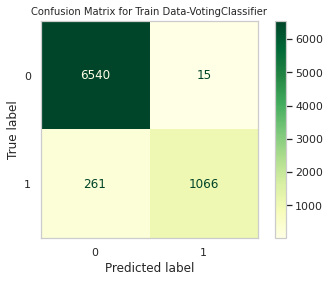

For class 0 Precision:0.96; class 1 Precision:0.99
For class 0 recall:1.0; class 1 recall:0.8
For class 0 fscore:0.98; class 1 fscore:0.89
AUC For VotingClassifier is :1.0


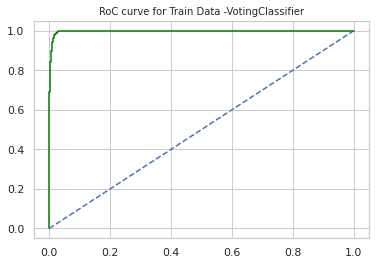

-----------------------------------------------------------------------------------------------------------------------------
time: 18.9 s (started: 2022-05-15 13:54:36 +00:00)


In [246]:
train_summary_m(VOTbyW_model)

### Test Data Performance

summary For Test Data of  VotingClassifier
score for VotingClassifier, is :0.95
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2809
           1       0.98      0.69      0.81       569

    accuracy                           0.95      3378
   macro avg       0.96      0.84      0.89      3378
weighted avg       0.95      0.95      0.94      3378

True Negative: 2801
False Negative: 176
False Postive: 8
True Postive: 393


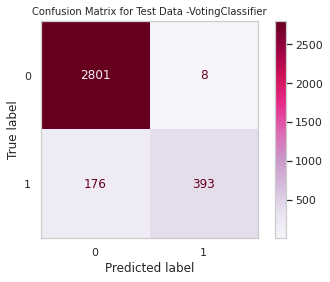

For class 0 Precision:0.94; class 1 Precision:0.98
For class 0 recall:1.0; class 1 recall:0.69
For class 0 fscore:0.97; class 1 fscore:0.81
AUC For VotingClassifier is :0.98


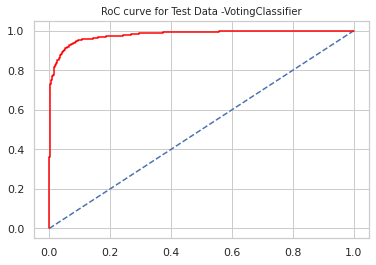

-----------------------------------------------------------------------------------------------------------------------------
time: 9.15 s (started: 2022-05-15 13:54:55 +00:00)


In [247]:
test_summary_m(VOTbyW_model)

## Stacking Classifier

In [136]:
from sklearn.ensemble import StackingClassifier
stacker = LogisticRegression()
STA_model = StackingClassifier(estimators=estim_list,final_estimator = stacker,n_jobs=-1)
STA_model.fit(X_train,y_train)

StackingClassifier(estimators=[('NB_model', GaussianNB()),
                               ('DT_model',
                                DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=442,
                                                       min_impurity_decrease=0.0005867593752795177,
                                                       min_samples_leaf=18,
                                                       min_samples_split=102)),
                               ('KNN_model',
                                Pipeline(steps=[('std_scaler',
                                                 StandardScaler()),
                                                ('model_KNN',
                                                 KNeighborsClassifier(metric='manhattan',
                                                                      n_neighbors=3,
                                                                      weights=...


time: 1min 39s (started: 2022-05-15 11:34:03 +00:00)


### Train Data Performance

summary For Train Data of  StackingClassifier
score for StackingClassifier, is :1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6555
           1       1.00      1.00      1.00      1327

    accuracy                           1.00      7882
   macro avg       1.00      1.00      1.00      7882
weighted avg       1.00      1.00      1.00      7882

True Negative: 6555
False Negative: 0
False Postive: 0
True Postive: 1327


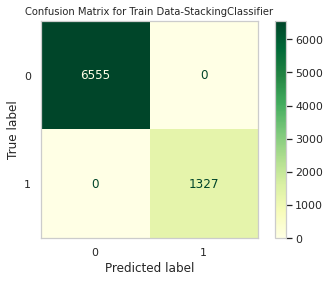

For class 0 Precision:1.0; class 1 Precision:1.0
For class 0 recall:1.0; class 1 recall:1.0
For class 0 fscore:1.0; class 1 fscore:1.0
AUC For StackingClassifier is :1.0


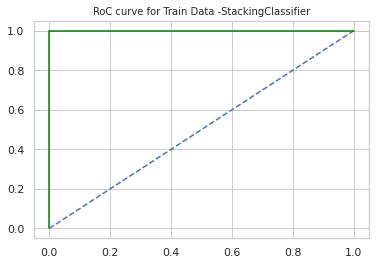

-----------------------------------------------------------------------------------------------------------------------------
time: 20 s (started: 2022-05-15 13:55:04 +00:00)


In [248]:
train_summary_m(STA_model)

### Test Data Performance

summary For Test Data of  StackingClassifier
score for StackingClassifier, is :0.98
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2809
           1       0.97      0.93      0.95       569

    accuracy                           0.98      3378
   macro avg       0.98      0.96      0.97      3378
weighted avg       0.98      0.98      0.98      3378

True Negative: 2792
False Negative: 37
False Postive: 17
True Postive: 532


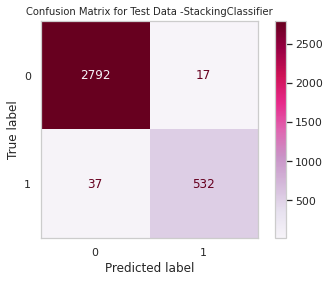

For class 0 Precision:0.99; class 1 Precision:0.97
For class 0 recall:0.99; class 1 recall:0.93
For class 0 fscore:0.99; class 1 fscore:0.95
AUC For StackingClassifier is :1.0


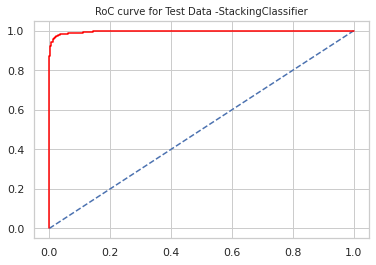

-----------------------------------------------------------------------------------------------------------------------------
time: 9.37 s (started: 2022-05-15 13:55:24 +00:00)


In [249]:
test_summary_m(STA_model)

# Model Comparison

In [139]:
models= [NB_model,DT_model,KNN_model,ANN_model,RF_model,ldam,LR_model,SVC_model,ADA_model,XGB_model,VOTbyW_model,STA_model]
models_list = ["NB_model","DT_model","KNN_model","ANN_model","RF_model","LDA_model","LR_model","SVC_Model","ADA_model","XGB_model","VOTbyW_model","STA_model"]

time: 2.19 ms (started: 2022-05-15 11:36:12 +00:00)


In [291]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
acc=[]
pre=[]
rec=[]
f1=[]
auc=[]
for i in models:
    acc.append(accuracy_score(y_test,i.predict(X_test)))
    pre.append(precision_score(y_test,i.predict(X_test),zero_division=0))
    rec.append(recall_score(y_test,i.predict(X_test)))
    f1.append(f1_score(y_test,i.predict(X_test)))
    probs=i.predict_proba(X_train)
    probs=probs[:,1]
    auc.append(roc_auc_score(y_train, probs))

time: 42.9 s (started: 2022-05-15 18:02:36 +00:00)


In [292]:
metric_df_test = pd.DataFrame({'Model':models_list,'Accuracy':acc,'Precision':pre,'Recall':rec,'F1_Score':f1,"AUC": auc})    
metric_df_test.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1_Score,AUC
11,STA_model,0.984014,0.969035,0.934974,0.951699,1.000000
2,KNN_model,0.973653,0.928571,0.913884,0.921169,1.000000
4,RF_model,0.966844,0.987207,0.813708,0.892100,1.000000
3,ANN_model,0.965660,0.902309,0.892794,0.897527,0.999993
10,VOTbyW_model,0.945530,0.980050,0.690685,0.810309,0.997985
7,SVC_Model,0.920663,0.916898,0.581722,0.711828,0.959688
8,ADA_model,0.900533,0.776722,0.574692,0.660606,0.918889
1,DT_model,0.897573,0.730849,0.620387,0.671103,0.953901
9,XGB_model,0.896684,0.810734,0.504394,0.621885,0.912736
6,LR_model,0.883955,0.780952,0.432337,0.556561,0.870053


time: 22.9 ms (started: 2022-05-15 18:03:19 +00:00)


## Cutoff Analysis

In [185]:
  Cutoff_model=STA_model.predict_proba(X_test)[:,1]
  cut_off = list(np.arange(0,1,0.005))
  acc = []
  pre = []
  rec = []
  for j in cut_off:
    pred = np.where(Cutoff_model>j,1,0)
    acc.append(accuracy_score(y_test,pred))
    pre.append(precision_score(y_test,pred,zero_division = 0))
    rec.append(recall_score(y_test,pred,zero_division =0))
  cut_off_analysis = pd.DataFrame({'Cut_off':cut_off,'Accuracy':acc,'Precision':pre,'Recall':rec})  

time: 3.15 s (started: 2022-05-15 13:21:20 +00:00)


Text(0.5, 1.0, 'Cut-off Analysis')

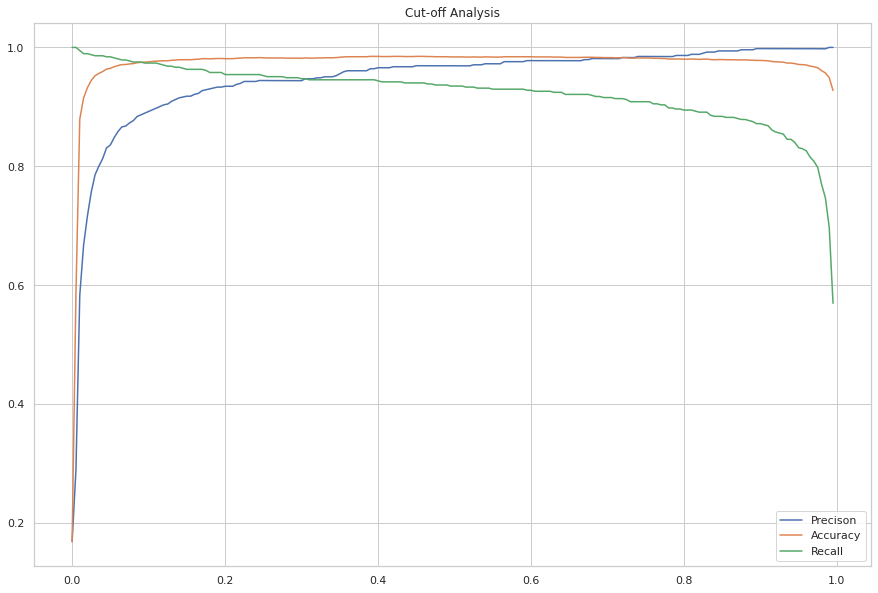

time: 388 ms (started: 2022-05-15 13:21:24 +00:00)


In [186]:
fig,axes = plt.subplots(figsize = (15,10))
plt.plot(cut_off,cut_off_analysis['Precision'],label='Precison')
plt.plot(cut_off,cut_off_analysis['Accuracy'],label='Accuracy')
plt.plot(cut_off,cut_off_analysis['Recall'],label='Recall')
plt.legend()
plt.title('Cut-off Analysis')